# Import Libraries

In [ ]:
# random number generation 
import random 

# numerical and data manipulation libraries
import numpy as np
import pandas as pd

# data visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# path manipulation and file handling
import os

# Computer Vision and image processing
import matplotlib.image as mpimg
import visualkeras
from PIL import Image  # Python Imaging Library for alternative image loading

# evaluation metrics 
from sklearn.metrics import classification_report, confusion_matrix

# deep learning frameworks
import keras

# model architecture and training utilities (use public API)
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D,Dropout,BatchNormalization
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from keras.models import load_model
from keras.utils import plot_model
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings('ignore')

# Import Data

In [ ]:
# Importing the dataset
train_path = 'D:/UTM/SEM 2/AI/Assignment/Project 2/Fruits and Vegetables Dataset/train'
test_path = 'D:/UTM/SEM 2/AI/Assignment/Project 2/Fruits and Vegetables Dataset/test'
validate_path = 'D:/UTM/SEM 2/AI/Assignment/Project 2/Fruits and Vegetables Dataset/validation'

# Data Visualization

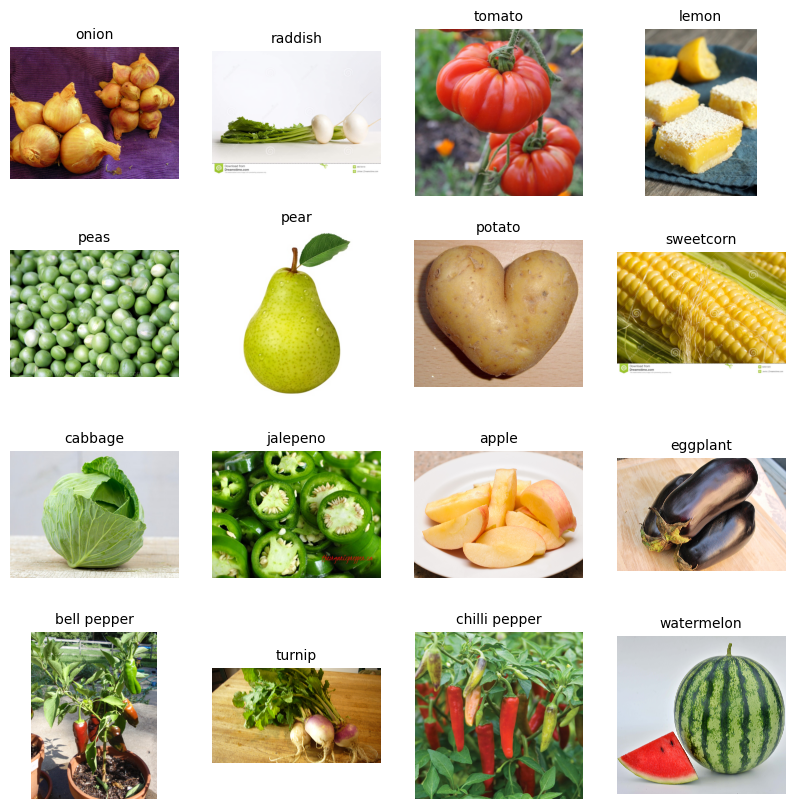

In [ ]:
# Get the list of all subdirectories (classes)
classes = os.listdir(train_path)

# Initialize an empty list to store file paths
image_paths = []

# Loop through each class folder and collect a few image paths
for cls in classes:
    class_dir = os.path.join(train_path, cls)
    images = os.listdir(class_dir)
    for img in images:
        image_paths.append(os.path.join(class_dir, img))

# Randomly select 16 images from the test set
random_images = random.sample(image_paths, 16)

# Set up a 4x4 grid for plotting
fig, axes = plt.subplots(4, 4, figsize=(10, 10))

# Loop through the grid and add an image to each subplot
for i, ax in enumerate(axes.flat):
    img = mpimg.imread(random_images[i])
    ax.imshow(img)
    # Extract the class name from the image path
    label = os.path.basename(os.path.dirname(random_images[i]))
    ax.set_title(label, fontsize=10)
    ax.axis('off')  # Hide axes

# Display the plot
plt.show()

As we can see in this plot, the images are in different shapes.We may need to resizing images to a standard size 

# Exploration Data Analysis

In [ ]:
def get_image_count(path):
    classes = os.listdir(path)
    image_count = {cls: len(os.listdir(os.path.join(path, cls))) for cls in classes}
    return image_count

# Get image count for each split
train_count = get_image_count(train_path)
test_count = get_image_count(test_path)
valid_count = get_image_count(validate_path)


In [ ]:
# Build a dataframe for a split
def build_df(path, split_name):
    data = []
    for cls in os.listdir(path):
        folder = os.path.join(path, cls)
        if not os.path.isdir(folder): continue
        num_images = len(os.listdir(folder))
        data.extend([{'class': cls, 'split': split_name}] * num_images)
    return pd.DataFrame(data)

# Build dataframes
df_train = build_df(train_path, 'Train')
df_valid = build_df(validate_path, 'Validation')
df_test  = build_df(test_path, 'Test')

# Combine all data
df = pd.concat([df_train, df_valid, df_test], ignore_index=True)

# Plot the count of each category
fig = px.bar(df, x='class', color='split', barmode='group',
             title='Image Counts per Class for Train, Validation, and Test Sets')
fig.update_layout(xaxis_title='Class',xaxis_tickangle=-45, yaxis_title='Number of Images')
fig.show()

In [ ]:
# Print overall counts
def print_summary(split_name, image_count):
    total_images = sum(image_count.values())
    num_classes = len(image_count)
    print(f"Found {total_images} images belonging to {num_classes} classes in {split_name}.")

print_summary("training", train_count)
print_summary("testing", test_count)
print_summary("validation", valid_count)

Found 3115 images belonging to 36 classes in training.
Found 359 images belonging to 36 classes in testing.
Found 351 images belonging to 36 classes in validation.


# Data Preprocessing      
->Resizing images to a standard size       
->Normalizing pixel values      
->No data augmentation used  

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,                 # Scaled images in range 0 to 1
    )

# train generator
train_generator = train_datagen.flow_from_directory(
    train_path,               
    target_size=(128, 128),
    class_mode='categorical',
    batch_size=16,
    seed=42
)

Found 3115 images belonging to 36 classes.


In [ ]:
# validation generator
validation_datagen = ImageDataGenerator(rescale=1./255,)

validation_generator = validation_datagen.flow_from_directory(
    validate_path,               
    target_size=(128, 128),
    class_mode='categorical',
    batch_size=16,
    seed=42
)

Found 351 images belonging to 36 classes.


In [ ]:
# Test generator
test_datagen = ImageDataGenerator(rescale=1./255,)

test_generator = test_datagen.flow_from_directory(
    test_path,               
    target_size=(128, 128),
    class_mode='categorical',
    batch_size=16,
    seed=42
)

Found 359 images belonging to 36 classes.


# Convolutional Neural Network (CNN)    

In [ ]:
# define a custom Sequential Convolutional Neural Network (CNN)
model_cnn = Sequential()

# first convolutional layer with 128 filters, 3x3 kernel, ReLU activation
model_cnn.add(Conv2D(128, (3, 3), activation="relu", padding='same', input_shape=(128, 128, 3)))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# second convolutional layer with 128 filters
model_cnn.add(Conv2D(128, (3, 3), activation="relu", padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# third convolutional layer with 64 filters
model_cnn.add(Conv2D(64, (3, 3), activation="relu", padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# fourth convolutional layer with 128 filters
model_cnn.add(Conv2D(128, (3, 3), activation="relu", padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# fifth convolutional layer with 32 filters
model_cnn.add(Conv2D(32, (3, 3), activation="relu", padding='same'))
model_cnn.add(BatchNormalization())
model_cnn.add(MaxPooling2D(pool_size=(2, 2)))

# flatten the output before passing to dense layers
model_cnn.add(Flatten())

# fully connected layer with 512 units
model_cnn.add(Dense(512, activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(Dropout(0.2))

# fully connected layer with 128 units
model_cnn.add(Dense(128, activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(Dropout(0.2))

# fully connected layer with 64 units
model_cnn.add(Dense(64, activation='relu'))
model_cnn.add(BatchNormalization())
model_cnn.add(Dropout(0.1))

# output layer with softmax activation for catrgory classification
model_cnn.add(Dense(36, activation='softmax'))

# compile the model using Adam optimizer and catrgory cross-entropy loss
model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# display the model architecture summary
model_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 128)  │         3,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 32)       │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 679,364 (2.59 MB)

 Trainable params: 676,996 (2.58 MB)

 Non-trainable params: 2,368 (9.25 KB)

CNN model includes 5 convolutional layers, 3 dense layers, one dropout layer, and batch normalization layers. This structure is sufficient for this dataset.

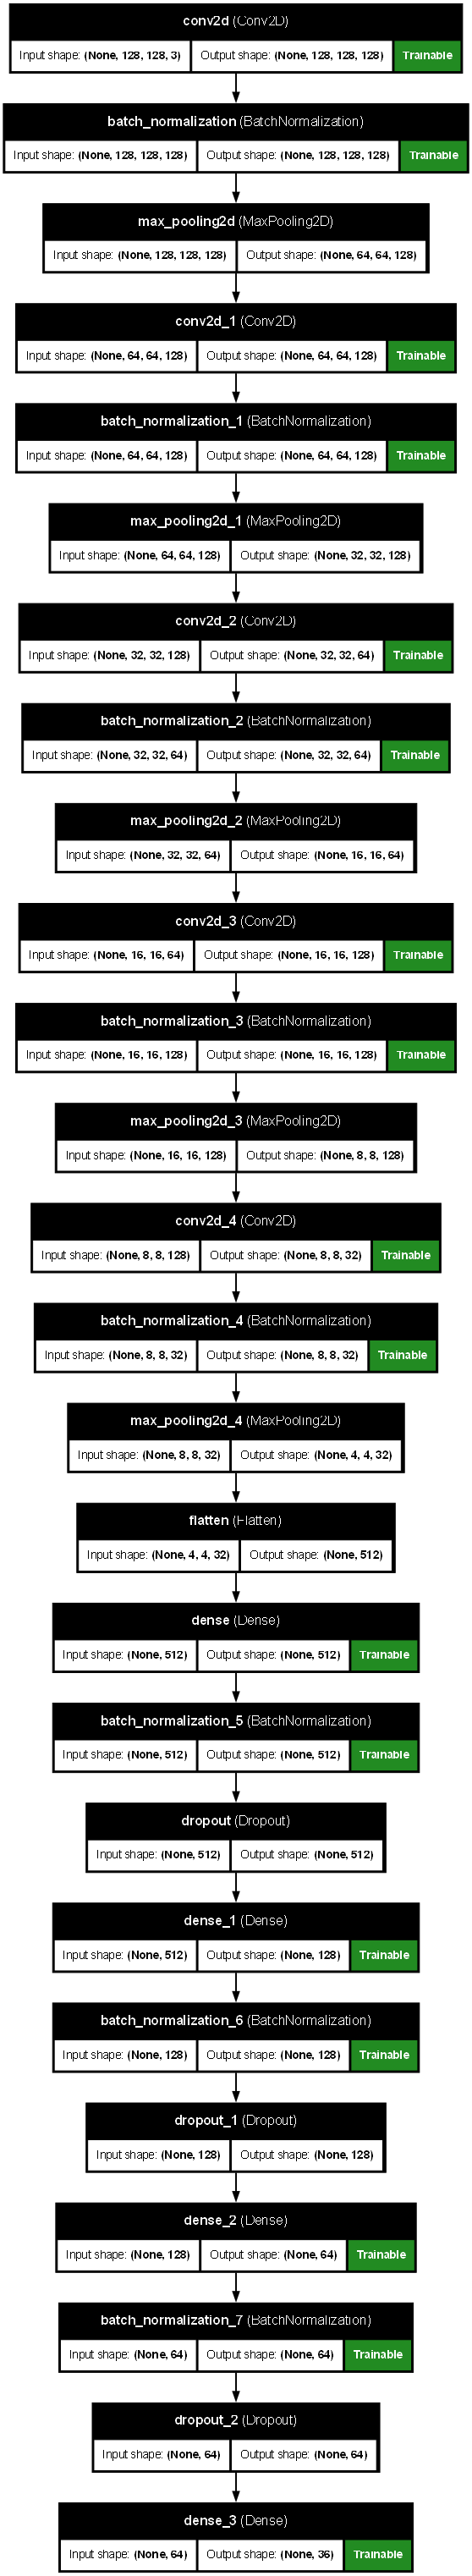

In [ ]:
# plot cnn model architecture
plot_model(
    model_cnn,
    to_file='model.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    dpi=70,
    show_layer_activations=False,
    show_trainable=True
)

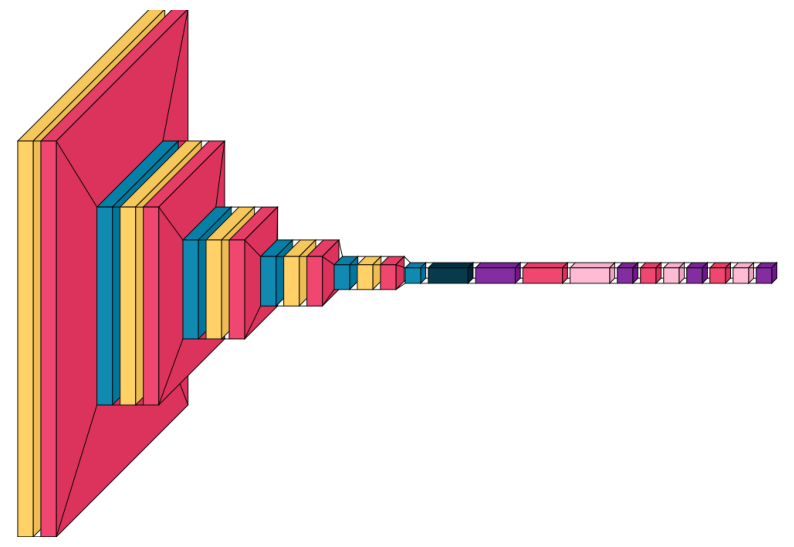

In [ ]:
from keras.utils import plot_model
plot_model(model_cnn, to_file='model_architecture.png', show_shapes=True)
visualkeras.layered_view(model_cnn).save('model_visualization.png')

# Display the image
img = Image.open('model_visualization.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

# Model Training

In [ ]:
# Reduce learning rate when validation loss plateaus
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,                # Reduce LR by this factor
    patience=5,                # Number of epochs with no improvement after which LR will be reduced
    min_lr=1e-6,               # Lower bound on the LR
    verbose=1
)

# Save the best model based on validation loss
model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',  # Filepath to save the best model
    monitor='val_accuracy',
    save_best_only=True,   # Only save when val_loss improves
    mode='max',   # Mode to determine the best model ('max' for validation accuracy)
    verbose=1
)

# Use all callbacks together in model.fit()
callbacks = [reduce_lr, model_checkpoint]

In [ ]:
# train the CNN model based on the training data and validation data
history_cnn = model_cnn.fit(
    train_generator,
    epochs=70,
    validation_data=validation_generator,
    callbacks=callbacks
)

Epoch 1/70
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 501ms/step - accuracy: 0.0694 - loss: 3.7562
Epoch 1: val_accuracy improved from -inf to 0.04274, saving model to best_model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 114s 569ms/step - accuracy: 0.0696 - loss: 3.7547 - val_accuracy: 0.0427 - val_loss: 4.5581 - learning_rate: 0.0010
Epoch 2/70
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 519ms/step - accuracy: 0.1958 - loss: 2.8784
Epoch 2: val_accuracy did not improve from 0.04274
195/195 ━━━━━━━━━━━━━━━━━━━━ 109s 556ms/step - accuracy: 0.1959 - loss: 2.8780 - val_accuracy: 0.0427 - val_loss: 3.7209 - learning_rate: 0.0010
Epoch 3/70
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.2526 - loss: 2.5190
Epoch 3: val_accuracy improved from 0.04274 to 0.48718, saving model to best_model.keras
195/195 ━━━━━━━━━━━━━━━━━━━━ 84s 430ms/step - accuracy: 0.2526 - loss: 2.5190 - val_accuracy: 0.4872 - val_loss: 1.8731 - learning_rate: 0.0010
Epoch 4/70
195/195 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.3012 - l

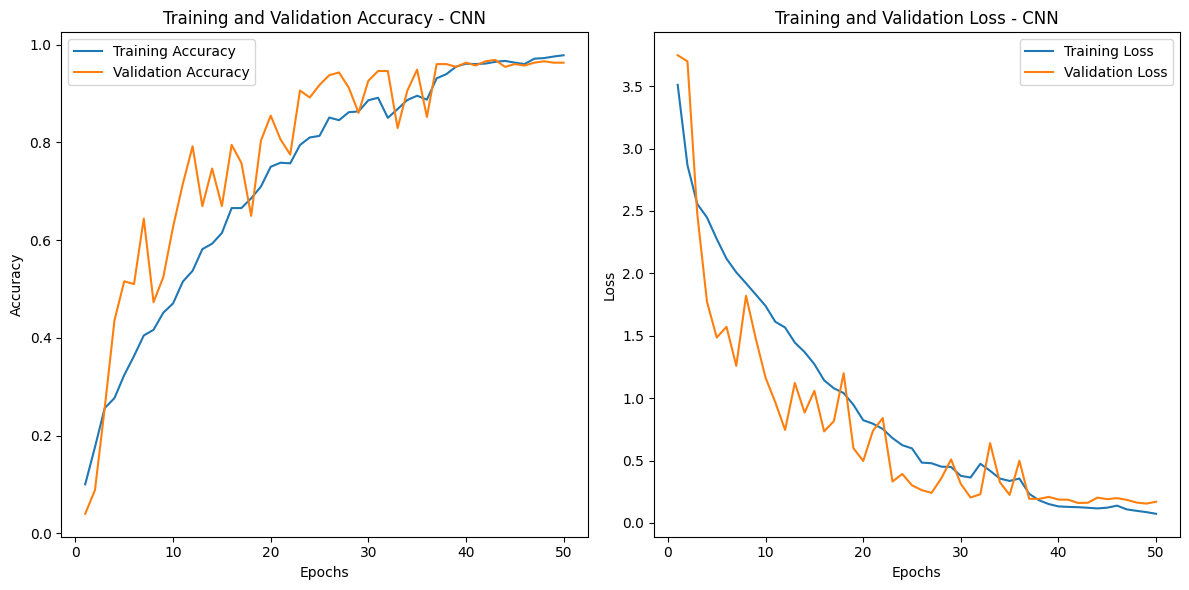

In [40]:
# function to plot training and validation accuracy(loss over epochs)
def plot_training_history(history):
    # extract training and validation metrics from history object
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)
    plt.figure(figsize=(12, 6))

    # plot training and validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Training Accuracy')
    plt.plot(epochs, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy - CNN')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # plot training and validation loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Training Loss')
    plt.plot(epochs, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss - CNN')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
    
# call the function to display training history plots
plot_training_history(history_cnn)

# Neural Network Evaluation

In [44]:
# Load the best saved model
best_model = load_model('best_model.keras')

# Evaluate the model on the test set
test_loss, test_accuracy = best_model.evaluate(test_generator)
print(f"Test Loss: {test_loss}")
print(f"Best model test accuracy: {test_accuracy:.4f}")

# Print the test accuracy by percentage
print(f'The accuracy of the best model on test dataset is: {(test_accuracy * 100):.4f}%')

23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 316ms/step - accuracy: 0.9612 - loss: 0.2429
Test Loss: 0.1577468365430832
Best model test accuracy: 0.9694
The accuracy of the best model on test dataset is: 96.9359%


In [45]:
# Initialize empty numpy arrays to store predicted classes and true labels
predictions = np.array([])
labels = np.array([])

# Reset the test generator to start from the first batch
test_generator.reset()

# Iterate through the test generator
for i in range(len(test_generator)):
    # Get the input data (x) and true labels (y)
    x, y = test_generator[i]
    
    # Use the model to predict the class probabilities of the input data
    predict_x = best_model.predict(x)
    
    # Convert the predicted probabilities to class predictions
    classes_x = np.argmax(predict_x, axis=1)
    
    # Add the predicted classes and true labels to the numpy arrays
    predictions = np.concatenate([predictions, classes_x])
    labels = np.concatenate([labels, np.argmax(y, axis=1)])  # Convert one-hot to class indices

# Convert the numerical labels to class names using the generator's class indices
label_names = {v: k for k, v in test_generator.class_indices.items()}

# Create a confusion matrix using the predicted classes and true labels
conf_matrix = confusion_matrix(labels, predictions, normalize='true')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


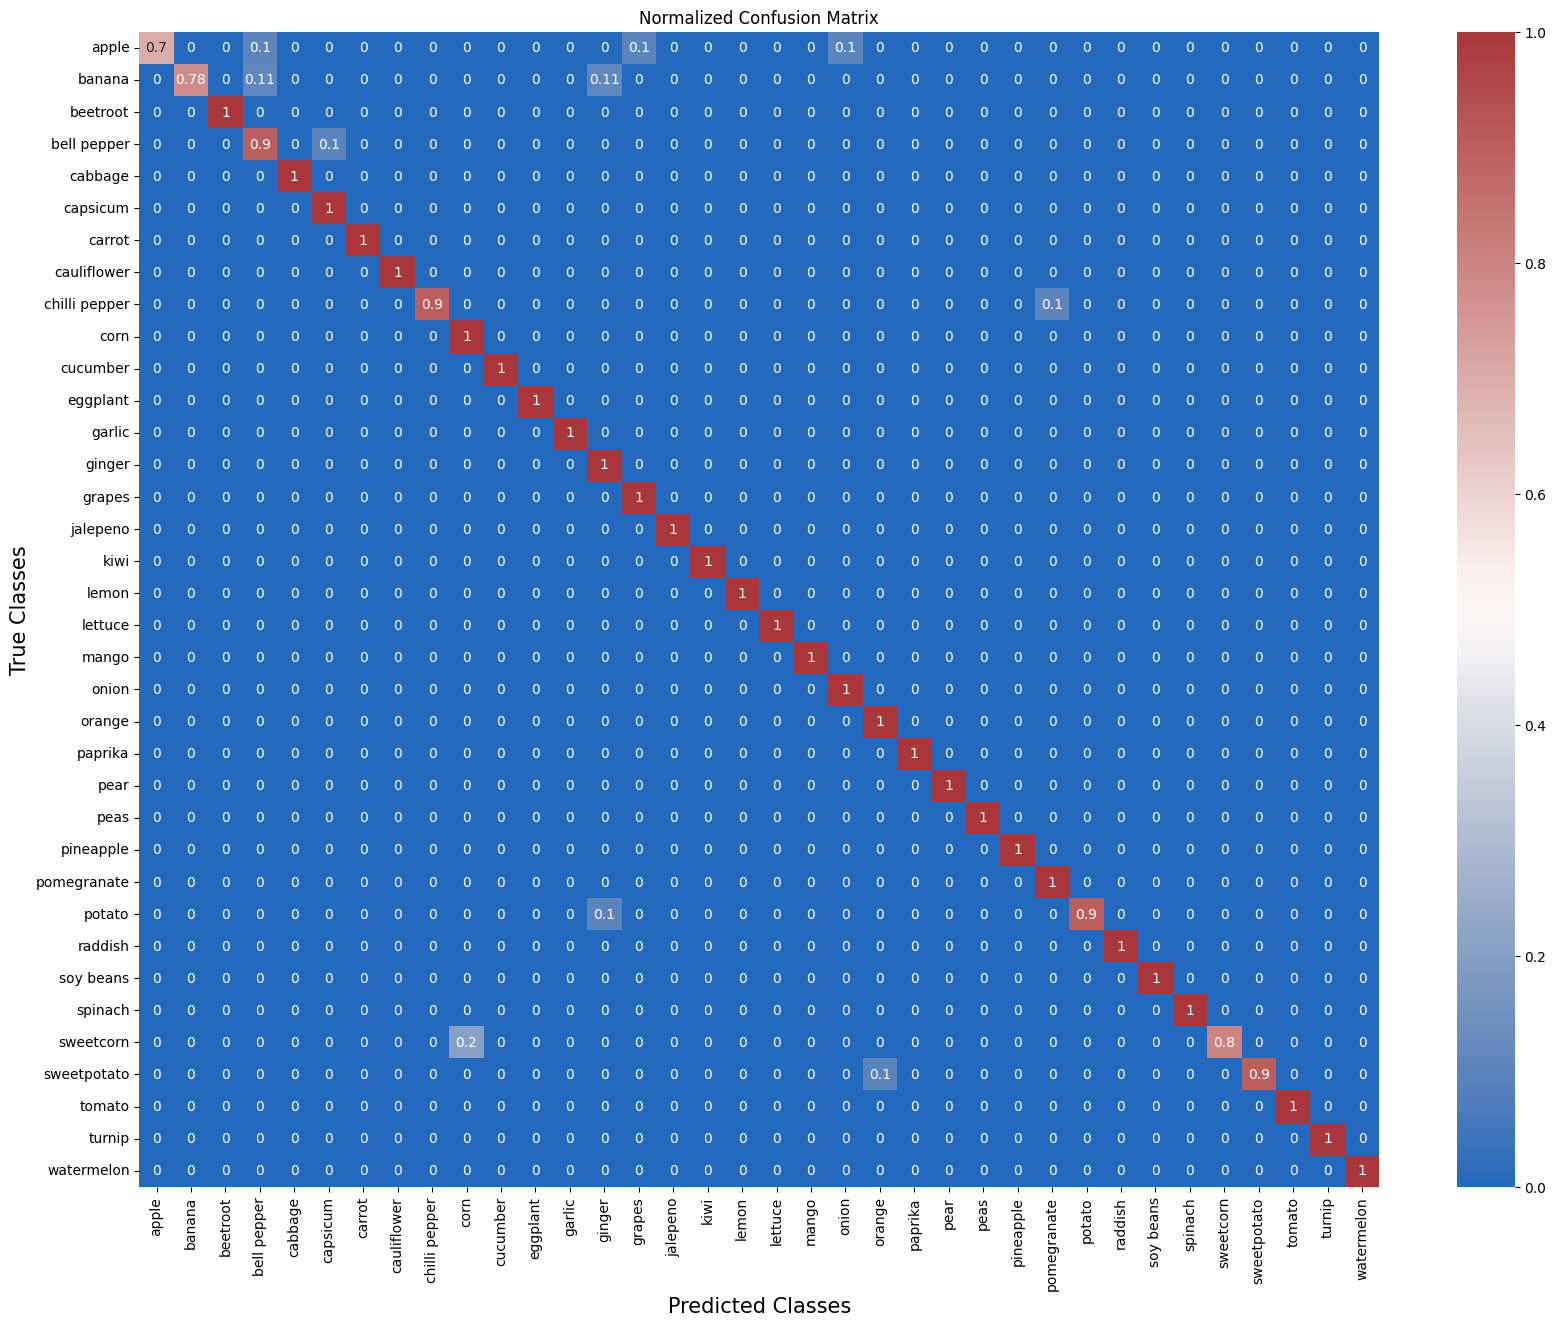

In [46]:
# Plot the confusion matrix as a heatmap
plt.figure(figsize=(20, 15))
sns.heatmap(conf_matrix,
            cmap='vlag',
            annot=True,
            xticklabels=[label_names[x] for x in sorted(set(labels))],
            yticklabels=[label_names[x] for x in sorted(set(labels))])
plt.xlabel("Predicted Classes", fontsize=15)
plt.ylabel("True Classes", fontsize=15)
plt.title('Normalized Confusion Matrix')
plt.show()

In [53]:
# generate a classification report including precision, recall, F1-score, and support for each class

# Convert numerical labels to class names using the generator's class indices
label_names = {v: k for k, v in test_generator.class_indices.items()}

# Generate classification report
class_report = classification_report(labels, predictions, target_names=[label_names[i] for i in sorted(label_names.keys())])

print("Classification Report:")
print(class_report)

Classification Report:
               precision    recall  f1-score   support

        apple       1.00      0.70      0.82        10
       banana       1.00      0.78      0.88         9
     beetroot       1.00      1.00      1.00        10
  bell pepper       0.82      0.90      0.86        10
      cabbage       1.00      1.00      1.00        10
     capsicum       0.91      1.00      0.95        10
       carrot       1.00      1.00      1.00        10
  cauliflower       1.00      1.00      1.00        10
chilli pepper       1.00      0.90      0.95        10
         corn       0.83      1.00      0.91        10
     cucumber       1.00      1.00      1.00        10
     eggplant       1.00      1.00      1.00        10
       garlic       1.00      1.00      1.00        10
       ginger       0.83      1.00      0.91        10
       grapes       0.91      1.00      0.95        10
     jalepeno       1.00      1.00      1.00        10
         kiwi       1.00      1.00      1